In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [67]:
import pandas as pd

df = pd.read_csv('../data/Titanic-Dataset.csv')

print("Dataset Loaded Successfully!")
df.head()

Dataset Loaded Successfully!


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [68]:
print("Shape:", df.shape)

df.info()

Shape: (891, 12)
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


In [69]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

# Task 1: Data Cleaning & Preprocessing

## Dataset Overview

The Titanic dataset contains passenger information including age, gender, ticket details, fare, cabin information, and survival status.

### Missing Values Found

- Age: 177 missing values
- Cabin: 687 missing values
- Embarked: 2 missing values

These missing values need to be handled before applying machine learning algorithms.

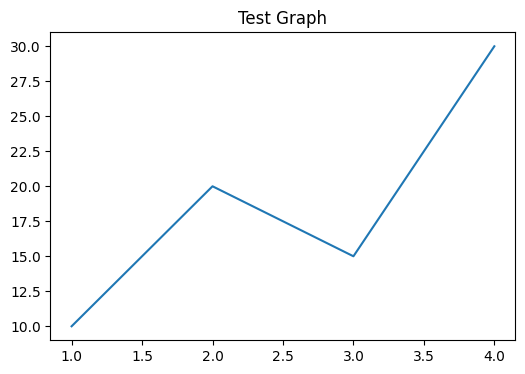

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
plt.plot([1,2,3,4],[10,20,15,30])

plt.title("Test Graph")

plt.show()

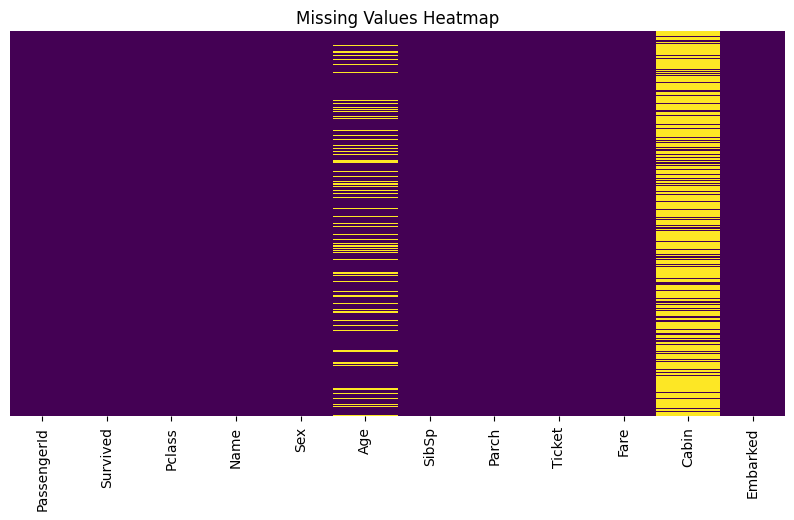

In [71]:
plt.figure(figsize=(10,5))

sns.heatmap(
    df.isnull(),
    yticklabels=False,
    cbar=False,
    cmap='viridis'
)

plt.title("Missing Values Heatmap")
plt.show()

In [72]:
df['Age'] = df['Age'].fillna(df['Age'].median())

df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

df.drop('Cabin', axis=1, inplace=True)

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [73]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

df[['SibSp', 'Parch', 'FamilySize']].head()

,SibSp,Parch,FamilySize
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


## Feature Engineering

A new feature called **FamilySize** was created using:

FamilySize = SibSp + Parch + 1

This feature represents the total number of family members traveling with a passenger and may provide additional insights for machine learning models.

In [74]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])

df[['Sex', 'Embarked']].head()

,Sex,Embarked
0,1,2
1,0,0
2,0,2
3,0,2
4,1,2


## Categorical Encoding

Machine learning models require numerical inputs.

The categorical columns:

- Sex
- Embarked

were converted into numerical values using Label Encoding.

In [75]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[['Age', 'Fare']] = scaler.fit_transform(df[['Age', 'Fare']])

df[['Age', 'Fare']].head()

,Age,Fare
0,-0.565736,-0.502445
1,0.663861,0.786845
2,-0.258337,-0.488854
3,0.433312,0.420730
4,0.433312,-0.486337


## Feature Scaling

The numerical features Age and Fare were standardized using StandardScaler.

This ensures that features are on a similar scale, which helps many machine learning algorithms perform better.

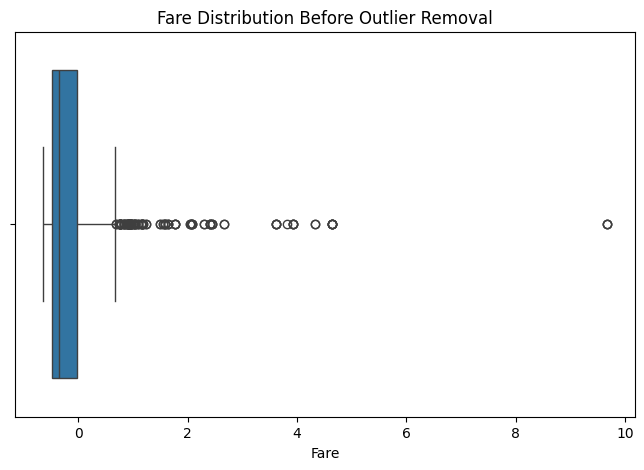

In [76]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Fare'])

plt.title("Fare Distribution Before Outlier Removal")
plt.show()

In [77]:
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['Fare'] >= lower_bound) &
        (df['Fare'] <= upper_bound)]

print("Rows after outlier removal:", df.shape[0])

Rows after outlier removal: 775


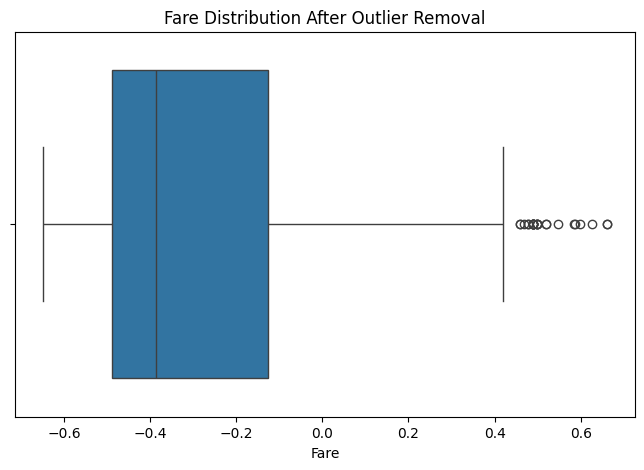

In [78]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Fare'])

plt.title("Fare Distribution After Outlier Removal")
plt.show()

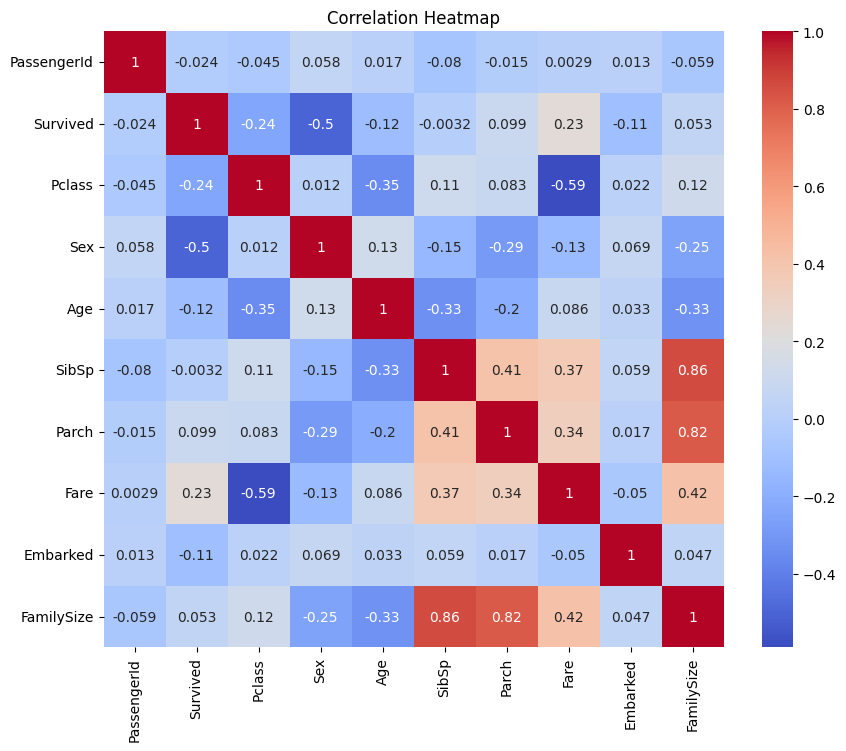

In [79]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.select_dtypes(include=['number']).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

## Correlation Analysis

A correlation heatmap was generated to identify relationships between numerical variables.

This helps understand feature interactions and can assist in future machine learning model development.

In [80]:
df.to_csv('../outputs/cleaned_titanic.csv', index=False)

print("Cleaned dataset exported successfully!")

Cleaned dataset exported successfully!


# Conclusion

The Titanic dataset was successfully preprocessed through:

- Missing value handling
- Feature engineering
- Label encoding
- Feature scaling
- Outlier detection and removal
- Correlation analysis

The final cleaned dataset is now ready for machine learning applications.